In [1]:
import sys
from pathlib import Path
from torch.utils.data import DataLoader

def find_repo_root(start_path=None):
    current = (start_path or Path.cwd()).resolve()
    while True:
        if (current / "data").is_dir() and (current / "data_setup").is_dir():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise RuntimeError("Could not locate necst-torch root directory")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from data_setup.dataloader import load_binarized_omniglot

# downloads if missing
train_ds, val_ds, test_ds = load_binarized_omniglot(REPO_ROOT / "data" / "Omniglot", download=True)

omniglot_train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
omniglot_valid_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
omniglot_test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

# quick sanity check
og_batch = next(iter(omniglot_train_loader))
print("Omniglot batch shape:", og_batch.shape, "min/max:", og_batch.min().item(), og_batch.max().item())


Omniglot batch shape: torch.Size([64, 1, 105, 105]) min/max: 0.0 1.0


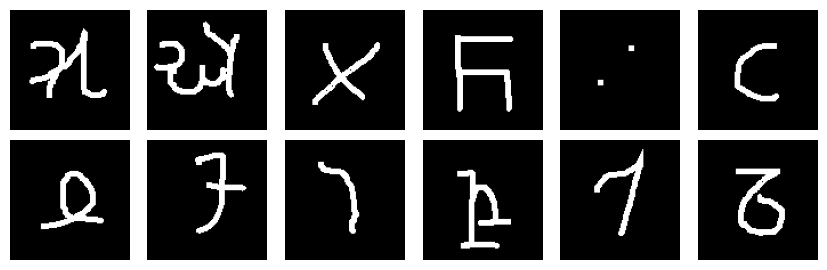

In [2]:
import matplotlib.pyplot as plt

def plot_omniglot(data_loader, n_rows=2, n_cols=6):
    batch = next(iter(data_loader))
    if isinstance(batch, (list, tuple)):
        imgs, labels = batch
    else:
        imgs, labels = batch, None

    imgs = imgs[: n_rows * n_cols].cpu()
    h, w = imgs.shape[-2], imgs.shape[-1]
    imgs = imgs.view(-1, h, w)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.4, n_rows * 1.4))
    for idx, img in enumerate(imgs):
        r, c = divmod(idx, n_cols)
        axes[r, c].imshow(img, cmap="gray_r", vmin=0, vmax=1)
        if labels is not None:
            axes[r, c].set_title(str(int(labels[idx])), fontsize=8)
        axes[r, c].axis("off")
    plt.tight_layout()
    plt.show()

plot_omniglot(omniglot_train_loader)
